# Face Recognition Demo (InsightFace + ONNXRuntime)

## What this notebook shows
This short demo implements a face recognition pipeline:

**Image → Face Detection → Face Embedding (vector) → Compare to Gallery → Identity**

We build a small "database" (gallery) of known people from a folder of images and then recognise faces in a new test image.

## Frameworks / Sources
- InsightFace: https://github.com/deepinsight/insightface
- ONNX Runtime: https://onnxruntime.ai/
- FaceAnalysis API (InsightFace): https://github.com/deepinsight/insightface/tree/master/python-package
- PCA (scikit-learn): https://scikit-learn.org/stable/modules/decomposition.html#pca

> Note: On macOS, CUDA is not available (NVIDIA-only). We use **CoreMLExecutionProvider** (if available) or CPU.

## 1) Setup

We import packages and define a few helper functions:
- **Cosine similarity** for comparing embeddings
- A simple `recognise_face()` function that returns the closest match from the gallery

In [24]:
from pathlib import Path
import numpy as np
import cv2
import matplotlib.pyplot as plt

import io
import contextlib
from insightface.app import FaceAnalysis
import onnxruntime as ort

In [25]:
# --- similarity helpers ---
def l2_normalize(x: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    return x / (np.linalg.norm(x) + eps)

def cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
    a = l2_normalize(a)
    b = l2_normalize(b)
    return float(np.dot(a, b))

def recognise_face(query_emb: np.ndarray, gallery: dict, threshold: float = 0.35):
    """
    Returns (name, score). If best score < threshold -> 'Unknown'
    Threshold depends on model/data; 0.30–0.45 is a common tuning range for cosine similarity.
    """
    if not gallery:
        return "Unknown", 0.0
    
    best_name = "Unknown"
    best_score = -1.0
    
    for name, emb in gallery.items():
        score = cosine_similarity(query_emb, emb)
        if score > best_score:
            best_score = score
            best_name = name
    
    if best_score < threshold:
        return "Unknown", best_score
    
    return best_name, best_score

## 2) Load the model (FaceAnalysis)

We use InsightFace's `FaceAnalysis` which can provide:
- face detection
- face recognition embeddings (typically **512-dimensional vectors**)
- optionally: **age/sex** via the `genderage` module

On macOS we request providers in this order:
**CoreML → CPU**

The models that could be used can be found here: https://github.com/deepinsight/insightface/tree/master/model_zoo

In [26]:
buffer = io.StringIO()

with contextlib.redirect_stdout(buffer), contextlib.redirect_stderr(buffer):
    app = FaceAnalysis(
        name="buffalo_l",
        allowed_modules=["detection", "recognition"],
        providers=["CoreMLExecutionProvider", "CPUExecutionProvider"], # CoreMLExecutionProvider is Apple Silion and CPUExecutionProvider is default CPU
    )
    app.prepare(ctx_id=-1, det_size=(640, 640))

# Capture logs
logs = buffer.getvalue().splitlines()

# Print only useful lines
for line in logs:
    if "find model" in line or "set det-size" in line:
        print(line)

print("Loaded models:", app.models.keys())

find model: /Users/josh/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
find model: /Users/josh/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)
Loaded models: dict_keys(['detection', 'recognition'])


### Model Initialisation Output

When `FaceAnalysis` is initialised, InsightFace loads pretrained models from the `buffalo_l` model pack. The line containing `det_10g.onnx` refers to the face detection model, which scans an input image and locates faces. The input shape `[1, 3, '?', '?']` describes the expected tensor format: a batch size of 1, three colour channels (RGB), and a flexible image height and width. The values `127.5 128.0` indicate the normalisation parameters used to scale pixel values before inference so the input matches the distribution used during training.

The line containing `w600k_r50.onnx` refers to the face recognition model, which takes a cropped face (fixed input size `112 × 112`) and converts it into a 512-dimensional embedding vector representing that face.

These embeddings are later compared to recognise identities. The line `set det-size: (640, 640)` sets the resolution used by the detection model, balancing speed and accuracy.

`Loaded models: dict_keys(['detection', 'recognition'])` confirms that only the detection and recognition modules were loaded from the model pack.

## 3) Build a small gallery (our "database")

We store one embedding per person using images in:

```
refs/
├── Amil.jpg
├── Tom.jpg
```


Each image is:
1) read with OpenCV  
2) processed by InsightFace  
3) first detected face is converted to an embedding vector  
4) stored in a dictionary: `gallery[name] = embedding`

In [27]:
ref_dir = Path("refs")
gallery = {}

for img_path in ref_dir.glob("*"):
    if not img_path.is_file():
        continue

    name = img_path.stem
    img = cv2.imread(str(img_path))
    if img is None:
        print(f"Could not read: {img_path}")
        continue

    faces = app.get(img)
    if len(faces) == 0:
        print(f"No face found in: {img_path}")
        continue

    # Take first face (for a clean demo)
    emb = faces[0].embedding.astype(np.float32)
    gallery[name] = emb

print("Loaded identities:", list(gallery.keys()))
if gallery:
    any_emb = next(iter(gallery.values()))
    print("Embedding shape example:", any_emb.shape)

Loaded identities: ['Tom', 'Amil']
Embedding shape example: (512,)


## 4) Recognition demo on a new image

We detect all faces in `test.jpg` and:
- draw bounding boxes
- compute an embedding per face
- compare it to the gallery using cosine similarity
- optionally display **age** and **sex** (if available)

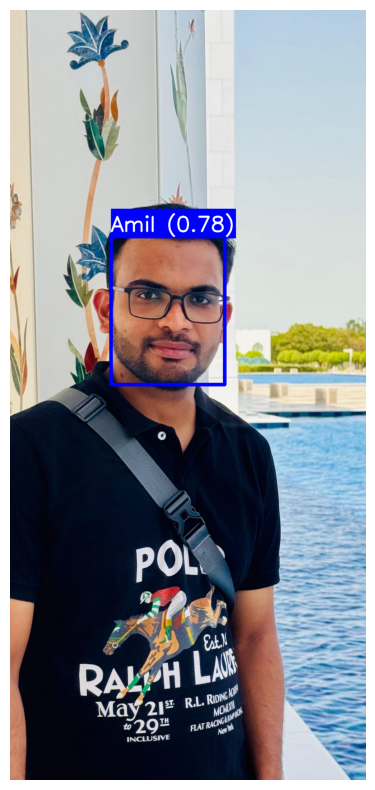

In [36]:
img = cv2.imread("amil2.PNG")

scale = max(img.shape[:2]) / 1000

box_thickness = int(4 * scale)
text_scale = 0.9 * scale
text_thickness = int(2 * scale)

faces = app.get(img)

for face in faces:

    x1, y1, x2, y2 = face.bbox.astype(int)

    emb = face.embedding
    name, score = recognise_face(emb, gallery)

    label = f"{name} ({score:.2f})"

    # box color is blue
    box_color = (255, 0, 0)

    # draw face box
    cv2.rectangle(img, (x1, y1), (x2, y2), box_color, box_thickness)

    # compute text size
    (text_w, text_h), baseline = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, text_scale, text_thickness)

    # position text above box if possible
    text_x = x1
    text_y = y1 - 10

    if text_y - text_h < 0:
        text_y = y1 + text_h + 10

    # draw filled rectangle behind text
    cv2.rectangle(img, (text_x, text_y - text_h - baseline), (text_x + text_w, text_y + baseline), box_color, -1)

    # draw text
    cv2.putText(img, label, (text_x, text_y), cv2.FONT_HERSHEY_SIMPLEX, text_scale, (255, 255, 255), text_thickness, cv2.LINE_AA)

# convert BGR to RGB - OpenCV reads images in BGR order by default so changing to a standard RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,10))
plt.imshow(img_rgb)
plt.axis("off")
plt.savefig("./image_predictions/amil_predict.jpg")
plt.show()

## 5) What are embeddings and why are they high-dimensional?

A **face embedding** is a numeric vector (often **512 dimensions**) that represents a face.

The recognition model learns an embedding space where:
- images of the **same person** produce vectors that are **close together**
- images of **different people** produce vectors that are **far apart**

### Why 512 dimensions?
Using higher dimensions gives the model more "room" to separate many identities.
If we tried to represent faces with only 2 dimensions, many different people would overlap in the same region, making reliable recognition difficult.

Humans can’t visualise 512D directly, so we use PCA to project to 2D for plotting.

## 6) PCA visualisation (2D)

We apply **PCA** to reduce embeddings from 512D → 2D for visualisation only.
This does **not** improve recognition; it just helps us *see* the embedding structure.

> With only one image per identity, we won’t get “clusters” yet — but you’ll still see separation.
> If you add multiple images per person (recommended), you’ll see clusters form.

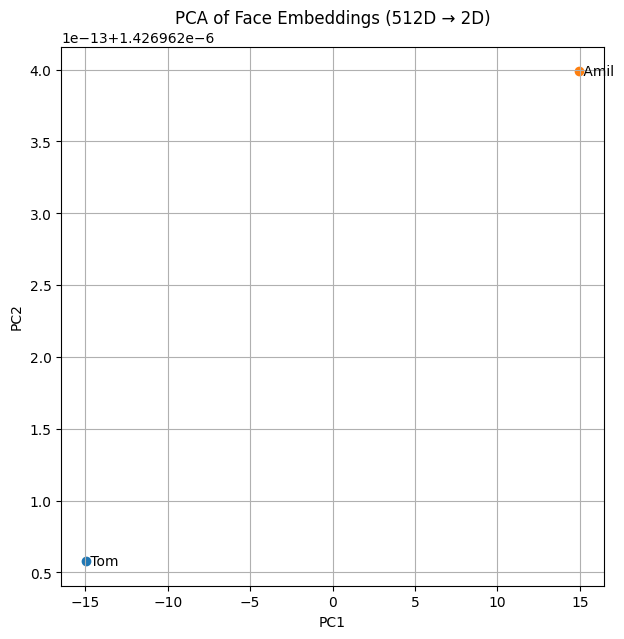

Explained variance ratio: [1.0000000e+00 9.0991955e-15]


In [29]:
from sklearn.decomposition import PCA

names = list(gallery.keys())
embs = np.array([gallery[n] for n in names], dtype=np.float32)

pca = PCA(n_components=2, random_state=0)
reduced = pca.fit_transform(embs)

plt.figure(figsize=(7, 7))
for i, n in enumerate(names):
    plt.scatter(reduced[i, 0], reduced[i, 1])
    plt.text(reduced[i, 0], reduced[i, 1], f" {n}", va="center")
plt.title("PCA of Face Embeddings (512D → 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)

## 8) Limitations / Notes

- Lighting, motion blur, occlusion (masks, hats), and extreme angles reduce accuracy.
- Recognition thresholds should be **tuned** for your dataset.
- A real system typically stores **multiple embeddings per person** and aggregates them (mean embedding).

## Summary
We demonstrated:
- face detection
- face embeddings
- similarity-based recognition
- optional age/sex attributes
- PCA visualisation of high-dimensional embeddings